# Hybrid dense LeJEPA — single-device (Mac CPU / MPS)

Train **`HybridDenseLeJEPAModel`** locally without DDP: one process, optional **Apple Silicon GPU** (`mps`) or **CPU**.

- Small model + few epochs for a smoke run.
- Same objective as the cluster script: dense invariance + SIGReg on aligned views.
- After training, optionally save a checkpoint compatible with `load_hybrid_dense_lejepa_from_checkpoint`.

**Requires:** `pip install -e .` from the repo root (or `pip install torch matplotlib`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# Repo root on disk (parent of examples/ if CWD is examples/)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def pick_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = pick_device()
print("PROJECT_ROOT:", PROJECT_ROOT)
print("device:", device)

PROJECT_ROOT: /Users/phzwart/Projects/convtrans
device: mps


In [2]:
# --- training knobs (keep small for Mac) ---
IMAGE_SIZE = 64
BATCH_SIZE = 4
NUM_EPOCHS = 15
LR = 1e-3

HIDDEN = 32
DEPTH = 4  # attention blocks
NUM_VIEWS = 2  # minimum for LeJEPA invariance
LATENT_DIM = 16

# Set True to step through views one-by-one (lower peak memory on CPU/MPS)
SEQUENTIAL_VIEWS = True

In [3]:
from local_conv_attention import DiscSquareDataset
from local_conv_attention.config import (
    DenseLatentConfig,
    DenseLeJEPAObjectiveConfig,
    HEAExperimentConfig,
    HEAUNetModelConfig,
)
from local_conv_attention.hybrid_dense_lejepa import HybridDenseLeJEPAModel
from local_conv_attention.hybrid_encoder import (
    HybridAttentionBlockConfig,
    HybridConvAttentionEncoderConfig,
    ResidualStemConfig,
)

model_cfg = HEAUNetModelConfig(
    name="hybrid_dense_lejepa",
    in_channels=1,
    act="gelu",
    hybrid_encoder=HybridConvAttentionEncoderConfig(
        stem=ResidualStemConfig(
            in_channels=1,
            hidden_channels=HIDDEN,
            kernel_size=3,
            stride=1,
            padding=1,
            use_bias=True,
        ),
        block=HybridAttentionBlockConfig(
            channels=HIDDEN,
            num_heads=4,
            window_size=7,
            dilation=1,
            implementation="optimized",
            boundary_pad="reflection",
            hidden_channels=HIDDEN * 4,
        ),
        depth=DEPTH,
        output_mode="feature_map",
    ),
    latent=DenseLatentConfig(
        source="encoder_out",
        step_mode="joint",
        latent_dim=LATENT_DIM,
        projector_depth=2,
        projector_kernel_size=3,
        normalize_latents=False,
    ),
    lejepa=DenseLeJEPAObjectiveConfig(
        num_views=NUM_VIEWS,
        sequential_view_forward=SEQUENTIAL_VIEWS,
        lambda_sigreg=0.05,
    ),
)
model_cfg.lejepa.sigreg.enabled = True
model_cfg.lejepa.sigreg.num_slices = 32
model_cfg.lejepa.sigreg.num_knots = 17
model_cfg.lejepa.sigreg.per_view = True
model_cfg.lejepa.views.mode = "aligned_same_geometry"
model_cfg.lejepa.views.pre_corrupt_rotation = True
model_cfg.lejepa.views.pre_corrupt_rotation_deg = (0.0, 360.0)
model_cfg.lejepa.views.pre_corrupt_rotation_padding = "reflection"
model_cfg.lejepa.views.corruption.intensity_jitter = True
model_cfg.lejepa.views.corruption.blur = False
model_cfg.lejepa.views.corruption.gaussian_noise = True
model_cfg.lejepa.views.corruption.random_block_mask = True
model_cfg.lejepa.views.corruption.block_mask_ratio = 0.04
model_cfg.lejepa.views.corruption.block_mask_num_blocks = 8

experiment_cfg = HEAExperimentConfig(model=model_cfg)
experiment_cfg.validate()

model = HybridDenseLeJEPAModel(model_cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print(model_cfg)
print("params:", sum(p.numel() for p in model.parameters()))

HEAUNetModelConfig(name='hybrid_dense_lejepa', in_channels=1, num_classes=2, base_channels=32, channel_multipliers=[1, 2, 4, 8], encoder_depths=[2, 2, 2, 2], decoder_depths=[2, 2, 2], norm='batchnorm', act='gelu', use_raw_skips=False, patch_size=3, mlp_ratio=4.0, backbone_gradient_checkpointing=False, swin_window_size=7, swin_stage_heads=[2, 4, 8, 8], bottleneck_depth=1, bottleneck_window_size=5, bottleneck_dilation=1, trunk=TrunkConfig(type=None, hea_enabled=None, hea_enabled_decoder_stages=None, elevator_mode=None, fusion_mode=None, operator_backend=None, local_attention_boundary_pad=None), backbone=TrunkConfig(type=None, hea_enabled=None, hea_enabled_decoder_stages=None, elevator_mode=None, fusion_mode=None, operator_backend=None, local_attention_boundary_pad=None), attention=HEAAttentionConfig(operator_backend='optimized', fusion_mode='per_scale', elevator_mode='direct', heads=4, head_dim=16, out_bias=True, qkv_bias=True, local_attention_boundary_pad='zeros'), semantic_memory=Seman

In [4]:
# Small synthetic dataset (same family as DDP spawn demo)
train_ds = DiscSquareDataset(repeats_per_type=128)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
)
len(train_ds), len(train_loader)

(1024, 256)

In [5]:
history = {"loss": [], "inv_loss": [], "sigreg_loss": []}
global_step = 0
model.train()

for epoch in range(NUM_EPOCHS):
    running = {k: 0.0 for k in history}
    n_batches = 0
    for batch in train_loader:
        images = batch["image"].to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(images, rotate_latent_index=global_step)
        global_step += 1
        out["loss"].backward()
        optimizer.step()
        for k in history:
            running[k] += float(out[k].detach())
        n_batches += 1
    for k in history:
        history[k].append(running[k] / max(n_batches, 1))
    print(
        f"epoch {epoch + 1}/{NUM_EPOCHS} | loss={history['loss'][-1]:.4f} | "
        f"inv={history['inv_loss'][-1]:.4f} | sigreg={history['sigreg_loss'][-1]:.4f}"
    )

epoch 1/15 | loss=0.0100 | inv=0.0007 | sigreg=0.1852
epoch 2/15 | loss=0.0093 | inv=0.0011 | sigreg=0.1644
epoch 3/15 | loss=0.0096 | inv=0.0014 | sigreg=0.1639
epoch 4/15 | loss=0.0086 | inv=0.0015 | sigreg=0.1428
epoch 5/15 | loss=0.0087 | inv=0.0016 | sigreg=0.1445
epoch 6/15 | loss=0.0084 | inv=0.0016 | sigreg=0.1376
epoch 7/15 | loss=0.0088 | inv=0.0013 | sigreg=0.1512
epoch 8/15 | loss=0.0074 | inv=0.0012 | sigreg=0.1245
epoch 9/15 | loss=0.0069 | inv=0.0012 | sigreg=0.1151
epoch 10/15 | loss=0.0071 | inv=0.0013 | sigreg=0.1178
epoch 11/15 | loss=0.0068 | inv=0.0012 | sigreg=0.1124


KeyboardInterrupt: 

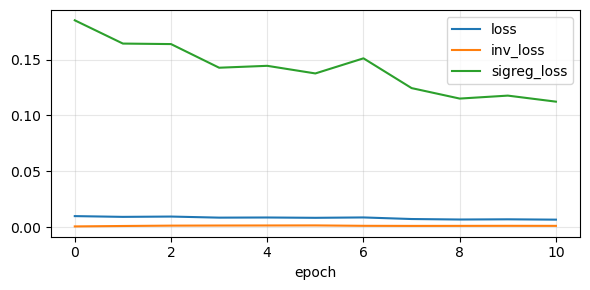

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(history["loss"], label="loss")
ax.plot(history["inv_loss"], label="inv_loss")
ax.plot(history["sigreg_loss"], label="sigreg_loss")
ax.set_xlabel("epoch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/sg/flwdvpwj6k1djjf0wn8f9q2w0000gn/T/ipykernel_59129/2181895329.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


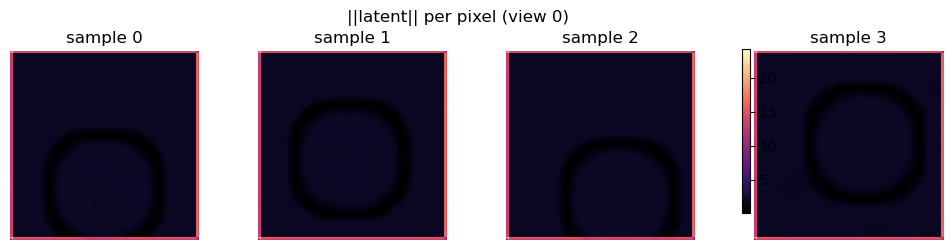

In [7]:
# Quick visualization: L2 norm of dense latents (view 0) on one batch
model.eval()
with torch.no_grad():
    batch = next(iter(train_loader))
    images = batch["image"].to(device)
    out = model(images)
    lat = out["latents"][:, 0]  # [B, D, H, W]
    norms = lat.norm(dim=1).cpu().numpy()

n_show = min(4, norms.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 2.5))
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    im = ax.imshow(norms[i], cmap="magma")
    ax.set_title(f"sample {i}")
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.85)
plt.suptitle("||latent|| per pixel (view 0)")
plt.tight_layout()
plt.show()

In [8]:
import napari
v = napari.Viewer()
v.add_image(out['latents'].cpu().numpy())

napari.manifest -> 'annotAIte' could not be imported: Could not find file 'napari_experimental_provide_dock_widget' in module 'napari_annotAIte._hooks'


<Image layer 'Image' at 0x3323c8250>

In [ ]:
# Optional: save a checkpoint (same keys as DDP spawn, for reload on cluster or inspection)
SAVE_DIR = PROJECT_ROOT / "examples" / "hybrid_mac_demo_outputs"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = SAVE_DIR / "checkpoint_latest.pt"

torch.save(
    {
        "epoch": NUM_EPOCHS,
        "global_step": global_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "config_dict": experiment_cfg.to_dict(),
    },
    ckpt_path,
)
print("saved:", ckpt_path)

# Reload sanity check
from examples.hybrid_dense_lejepa_ddp_spawn import load_hybrid_dense_lejepa_from_checkpoint

m2, cfg2 = load_hybrid_dense_lejepa_from_checkpoint(ckpt_path, map_location="cpu")
print("reload ok:", cfg2.model.name, "params match:", sum(p.numel() for p in m2.parameters()))